# 📊 PHASE zzity report + insights

---

In [1]:
# Set working directory to project root
import os
from pathlib import Path
from IPython.display import display

# Find project root robustly from the current notebook location or cwd
candidate_paths = [Path.cwd()] + list(Path.cwd().parents)
project_root = None
for candidate in candidate_paths:
    if (candidate / 'src' / 'scripts' / 'config.py').exists():
        project_root = candidate
        break

if project_root is None:
    raise FileNotFoundError("Unable to locate project root containing src/scripts/config.py")

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.insert(0, str(project_root / 'src' / 'scripts'))
from config import RAW_DATA_FILE, FORVIA_COLORS
from logger import get_logger

logger = get_logger(__name__)

# Visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_palette(FORVIA_COLORS)

print("✅ Imports successful!")

Working directory set to: c:\Users\1boughai\Desktop\IDP-Monitoring-Project
2026-05-25 09:51:03,593 - logger - INFO - 🔧 DEBUG MODE ENABLED
2026-05-25 09:51:03,594 - logger - INFO - 📝 Logs saved to: c:\Users\1boughai\Desktop\IDP-Monitoring-Project\src\outputs\project_20260525_095103.log
✅ Imports successful!


## 1️⃣ DATA LOADING & BASIC INFO

In [15]:
# Load data
logger.info(f"Loading data from {RAW_DATA_FILE}")
df = pd.read_csv(RAW_DATA_FILE, low_memory=False)

print(f"\n📊 DATASET OVERVIEW:")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Size: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\n📋 COLUMN NAMES (First 20):")
for i, col in enumerate(df.columns[:59], 1):
    print(f"  {i:2d}. {col}")


📊 DATASET OVERVIEW:
  Shape: 616,800 rows × 59 columns
  Size: 1294.2 MB

📋 COLUMN NAMES (First 20):
   1. purchasing_document_|_ebeln
   2. item_|_ebelp
   3. source
   4. plant_|_werks
   5. supplier_|_lifnr
   6. purchasing_doc_type_|_bsart
   7. purch_organization_|_ekorg
   8. purchasing_group_|_ekgrp
   9. document_date_|_bedat
  10. material_|_matnr
  11. material_group_|_matkl
  12. short_text_|_txz01
  13. order_unit_|_meins
  14. order_price_unit_|_bprme
  15. price_unit_|_peinh
  16. net_order_price_|_netpr
  17. quantity_|_menge
  18. amount_|_wrbtr
  19. amtin_loccur_|_dmbtr
  20. currency_|_waers
  21. movement_type_|_bwart
  22. po_history_category_|_bewtp
  23. debitcredit_ind_|_shkzg
  24. posting_date_|_budat
  25. reference_document_|_lfbnr
  26. reference_doc_item_|_lfpos
  27. reason_for_movement_|_grund
  28. deletion_indicator_|_loekz
  29. delivery_completed_|_elikz_ekpo
  30. invoice_value_|_reewr
  31. outline_agreement_|_konnr
  32. terms_of_payment_|_zterm


## 2️⃣ DATA TYPES & MISSING VALUES

In [8]:
# Data types
print("\n📋 DATA TYPES:")
print(df.dtypes.value_counts())

# Missing values
print(f"\n⚠️ MISSING VALUES (Top 20):")
missing = df.isnull().sum().sort_values(ascending=False).head(20)
missing_pct = (missing / len(df) * 100).round(2)

for col in missing.index:
    print(f"  {col:50s}: {missing[col]:7,} ({missing_pct[col]:5.1f}%)")


📋 DATA TYPES:
str        35
int64      12
float64    12
Name: count, dtype: int64

⚠️ MISSING VALUES (Top 20):
  outline_agreement_|_konnr                         : 616,800 (100.0%)
  deletion_indicator_|_loekz                        : 614,878 ( 99.7%)
  batch_|_charg                                     : 553,066 ( 89.7%)
  valuation_type_|_bwtar                            : 490,383 ( 79.5%)
  purchasing_info_rec_|_infnr                       : 446,448 ( 72.4%)
  movement_type_|_bwart                             : 306,392 ( 49.7%)
  region                                            : 258,119 ( 41.9%)
  vendor_material_no_|_idnlf                        : 108,146 ( 17.5%)
  unit_of_weight_|_gewei                            :  67,384 ( 10.9%)
  tax_code_|_mwskz                                  :  47,600 (  7.7%)
  storage_location                                  :  41,625 (  6.8%)
  delivery_completed_|_elikz_ekpo                   :   1,570 (  0.2%)
  city                              

## 3️⃣ SAP P2P KEY COLUMNS VERIFICATION

In [9]:
# Check critical columns
critical_cols = [
    'po_history_category_|_bewtp',
    'amount_|_wrbtr',
    'invoice_value_|_reewr',
    'purchasing_document_|_ebeln',
    'item_|_ebelp',
    'supplier_|_lifnr',
]

print("\n🔍 CRITICAL COLUMNS CHECK:")
print("=" * 80)

for col in critical_cols:
    if col in df.columns:
        non_null = df[col].notna().sum()
        pct = round(non_null / len(df) * 100, 2)
        print(f"✅ {col:50s}: {non_null:7,} / {len(df):,} ({pct:5.1f}%)")
    else:
        print(f"❌ {col:50s}: NOT FOUND")

# P2P category distribution with meanings
if 'po_history_category_|_bewtp' in df.columns:
    print(f"\n📊 P2P CATEGORIES DISTRIBUTION:")
    print("=" * 80)
    
    # Dictionnaire des significations
    category_meanings = {
        'E': 'Goods Receipt (GR - Livraison)',
        'Q': 'Invoice Receipt (IR - Facture)',
        'K': 'Return/Cancellation (Retour)',
        'N': 'Debit Note (Note de débit)',
        'W': 'Other (Autre)',
        'R': 'Return (Retour)',
    }
    
    # Obtenir les comptages
    counts = df['po_history_category_|_bewtp'].value_counts()
    percentages = df['po_history_category_|_bewtp'].value_counts(normalize=True) * 100
    
    # Afficher avec significations
    for category in counts.index:
        meaning = category_meanings.get(category, 'Unknown')
        count = counts[category]
        pct = percentages[category]
        print(f"  {category:2s} → {meaning:40s}: {count:7,} ({pct:6.2f}%)")


🔍 CRITICAL COLUMNS CHECK:
✅ po_history_category_|_bewtp                       : 616,800 / 616,800 (100.0%)
✅ amount_|_wrbtr                                    : 616,800 / 616,800 (100.0%)
✅ invoice_value_|_reewr                             : 616,800 / 616,800 (100.0%)
✅ purchasing_document_|_ebeln                       : 616,800 / 616,800 (100.0%)
✅ item_|_ebelp                                      : 616,800 / 616,800 (100.0%)
✅ supplier_|_lifnr                                  : 616,800 / 616,800 (100.0%)

📊 P2P CATEGORIES DISTRIBUTION:
  E  → Goods Receipt (GR - Livraison)          : 310,408 ( 50.33%)
  Q  → Invoice Receipt (IR - Facture)          : 303,027 ( 49.13%)
  K  → Return/Cancellation (Retour)            :   2,791 (  0.45%)
  N  → Debit Note (Note de débit)              :     308 (  0.05%)
  W  → Other (Autre)                           :     266 (  0.04%)


## 4️⃣ GR/IR COMBINATION ANALYSIS

In [10]:
# Analyze GR/IR combinations
print("\n🔍 GR/IR COMBINATIONS (Raw Level):")
print("=" * 80)

# Create flags
df['has_gr'] = df['po_history_category_|_bewtp'] == 'E'
df['has_ir'] = df['po_history_category_|_bewtp'] == 'Q'

# Group by (PO, Item) to check combinations
po_item_combos = df.groupby(['purchasing_document_|_ebeln', 'item_|_ebelp']).agg({
    'has_gr': 'any',
    'has_ir': 'any'
}).reset_index()

# Categorize
def categorize(row):
    if row['has_gr'] and row['has_ir']:
        return 'GR+IR (OK)'
    elif row['has_gr'] and not row['has_ir']:
        return 'GR only (PENDING_INVOICE)'
    elif not row['has_gr'] and row['has_ir']:
        return 'IR only (FRAUD!)'
    else:
        return 'Neither (INCOMPLETE)'

po_item_combos['category'] = po_item_combos.apply(categorize, axis=1)

# Stats
combo_dist = po_item_combos['category'].value_counts()
for cat, count in combo_dist.items():
    pct = count / len(po_item_combos) * 100
    print(f"  {cat:30s}: {count:7,} ({pct:5.1f}%)")

print(f"\n🚨 CRITICAL: {combo_dist.get('IR only (FRAUD!)', 0):,} transactions with IR but NO GR!")


🔍 GR/IR COMBINATIONS (Raw Level):
  GR+IR (OK)                    : 283,027 ( 95.7%)
  GR only (PENDING_INVOICE)     :  12,624 (  4.3%)

🚨 CRITICAL: 0 transactions with IR but NO GR!


## 5️⃣ DATA QUALITY ISSUES

In [11]:
print("\n⚠️ DATA QUALITY ISSUES:")
print("=" * 80)

issues = {
    'Null amount': df['amount_|_wrbtr'].isna().sum(),
    'Zero amount': (df['amount_|_wrbtr'] == 0).sum(),
    'Negative amount': (df['amount_|_wrbtr'] < 0).sum(),
    'Null invoice value': df['invoice_value_|_reewr'].isna().sum(),
    'Deleted items': df['deletion_indicator_|_loekz'].notna().sum() if 'deletion_indicator_|_loekz' in df.columns else 0,
}

for issue, count in issues.items():
    pct = count / len(df) * 100
    print(f"  {issue:30s}: {count:7,} ({pct:5.1f}%)")

print(f"\n📊 DUPLICATE PO+ITEM combinations: {len(df) - len(po_item_combos):,}")
print(f"   (Multiple transactions per PO line - normal in P2P)")


⚠️ DATA QUALITY ISSUES:
  Null amount                   :       0 (  0.0%)
  Zero amount                   :   8,600 (  1.4%)
  Negative amount               :       0 (  0.0%)
  Null invoice value            :       0 (  0.0%)
  Deleted items                 :   1,922 (  0.3%)

📊 DUPLICATE PO+ITEM combinations: 321,149
   (Multiple transactions per PO line - normal in P2P)


## 6️⃣ KEY STATISTICS

In [12]:
print("\n📈 AMOUNT STATISTICS:")
print("=" * 80)

for col in ['amount_|_wrbtr', 'invoice_value_|_reewr']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Count:   {df[col].notna().sum():,}")
        print(f"  Mean:    ${df[col].mean():,.2f}")
        print(f"  Median:  ${df[col].median():,.2f}")
        print(f"  Std:     ${df[col].std():,.2f}")
        print(f"  Min:     ${df[col].min():,.2f}")
        print(f"  Max:     ${df[col].max():,.2f}")


📈 AMOUNT STATISTICS:

amount_|_wrbtr:
  Count:   616,800
  Mean:    $1,639.99
  Median:  $230.00
  Std:     $16,380.03
  Min:     $0.00
  Max:     $5,132,640.00

invoice_value_|_reewr:
  Count:   616,800
  Mean:    $1,524.92
  Median:  $0.00
  Std:     $15,516.47
  Min:     $0.00
  Max:     $5,669,888.33


## 7️⃣ EXPLORATORY DATA ANALYSIS (EDA)



📊 EDA OVERVIEW
Dataset shape: 616,800 rows × 59 columns
Selected monetary columns: 2


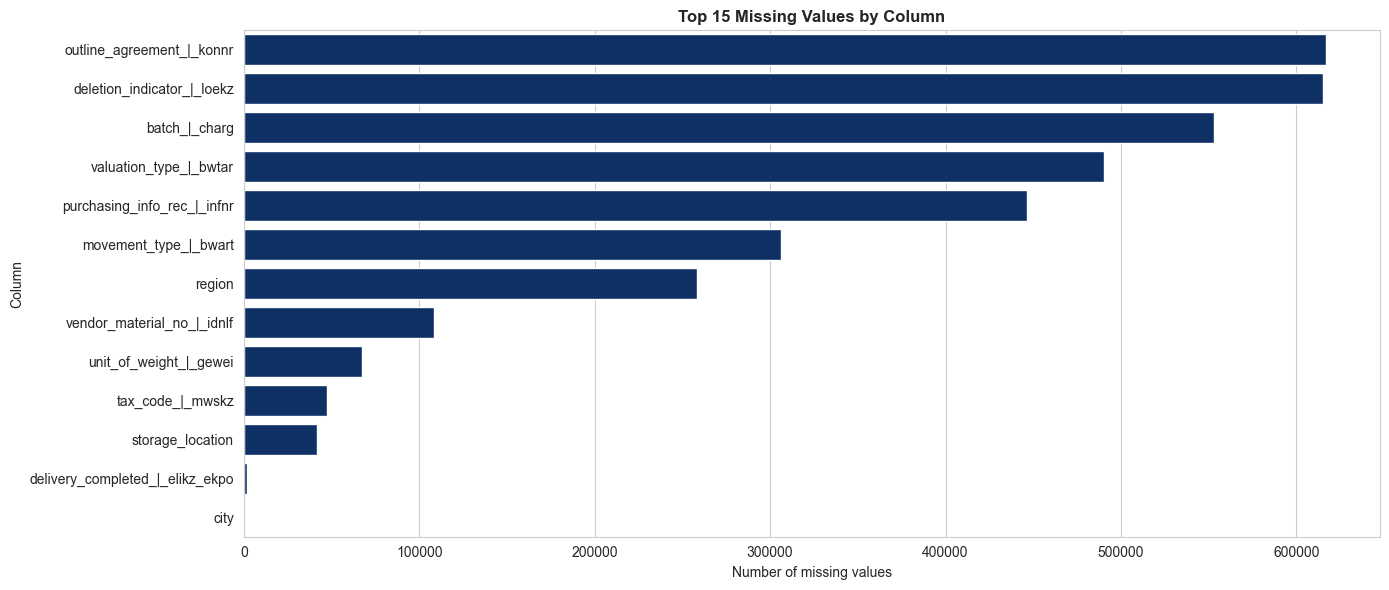

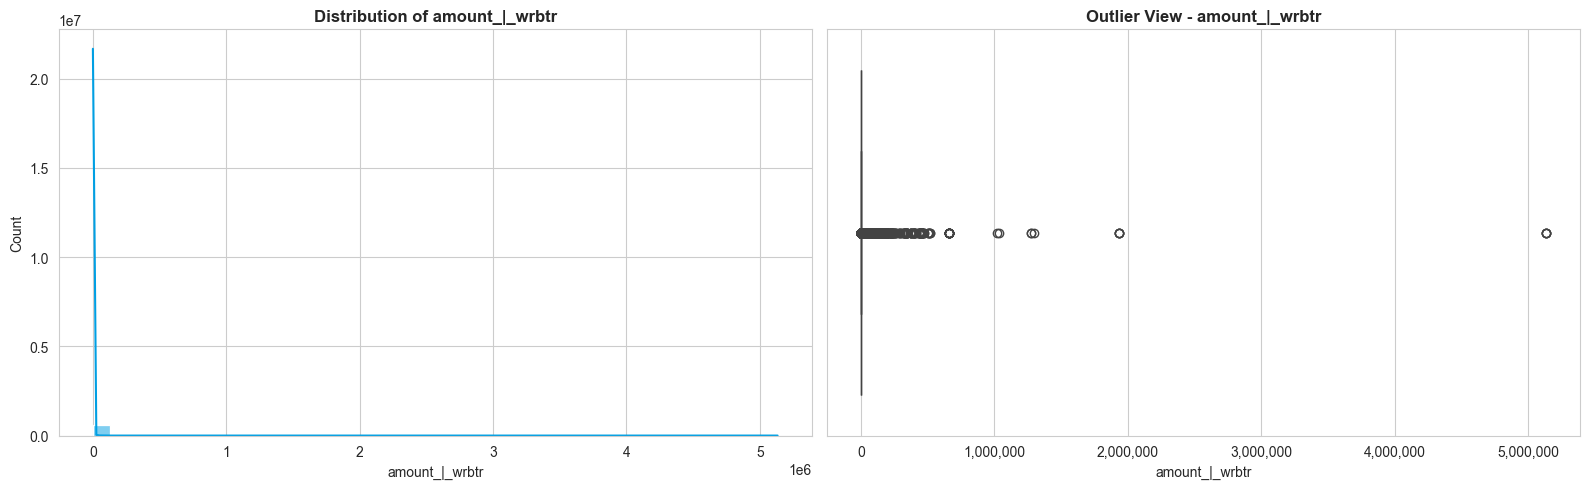

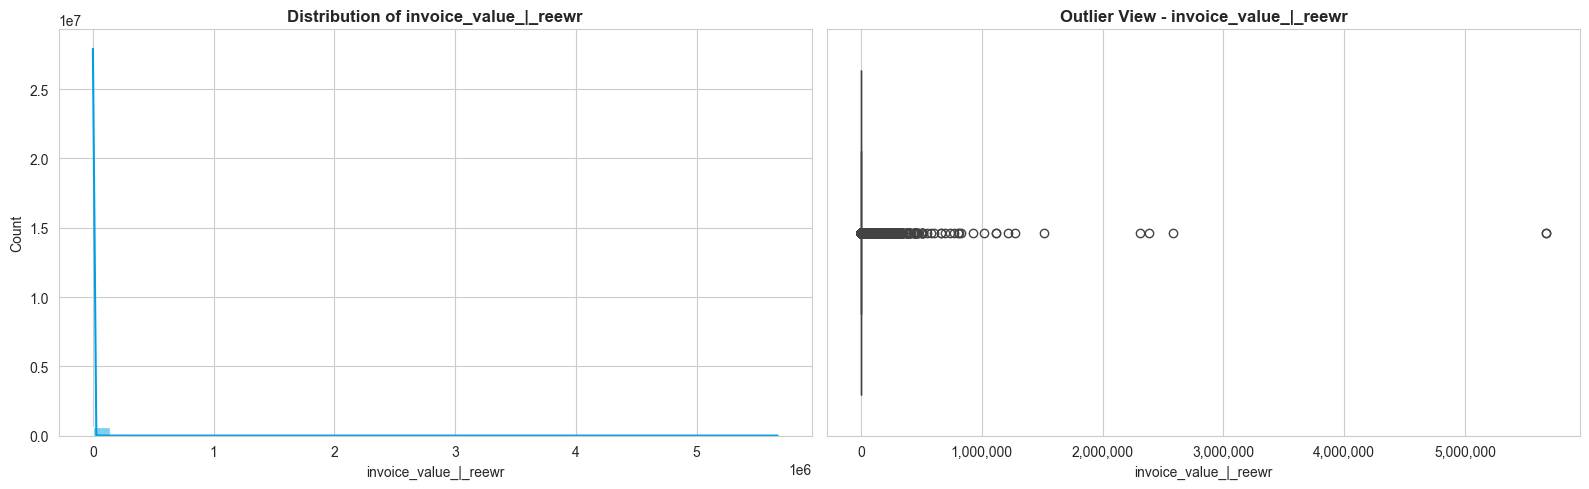

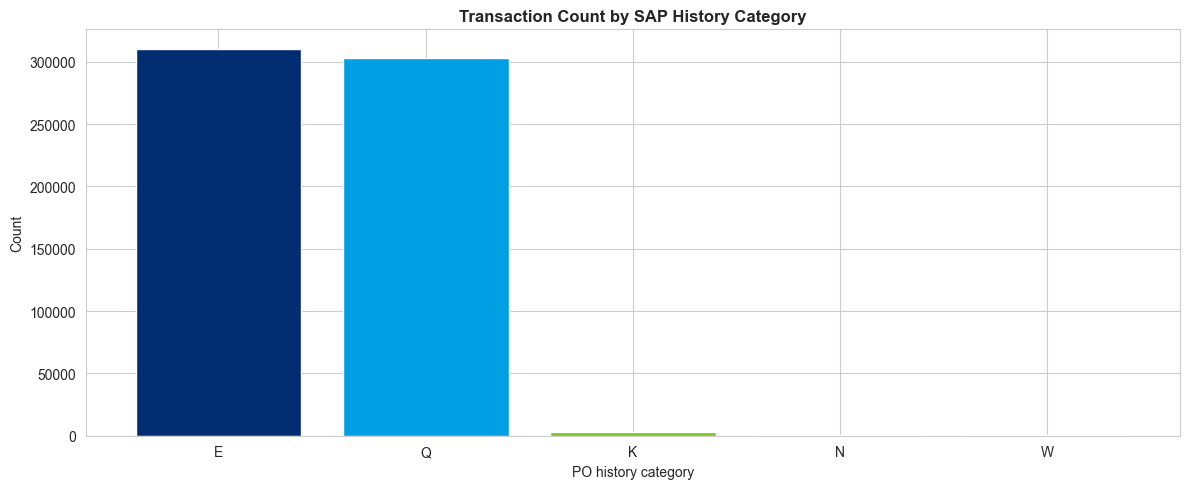

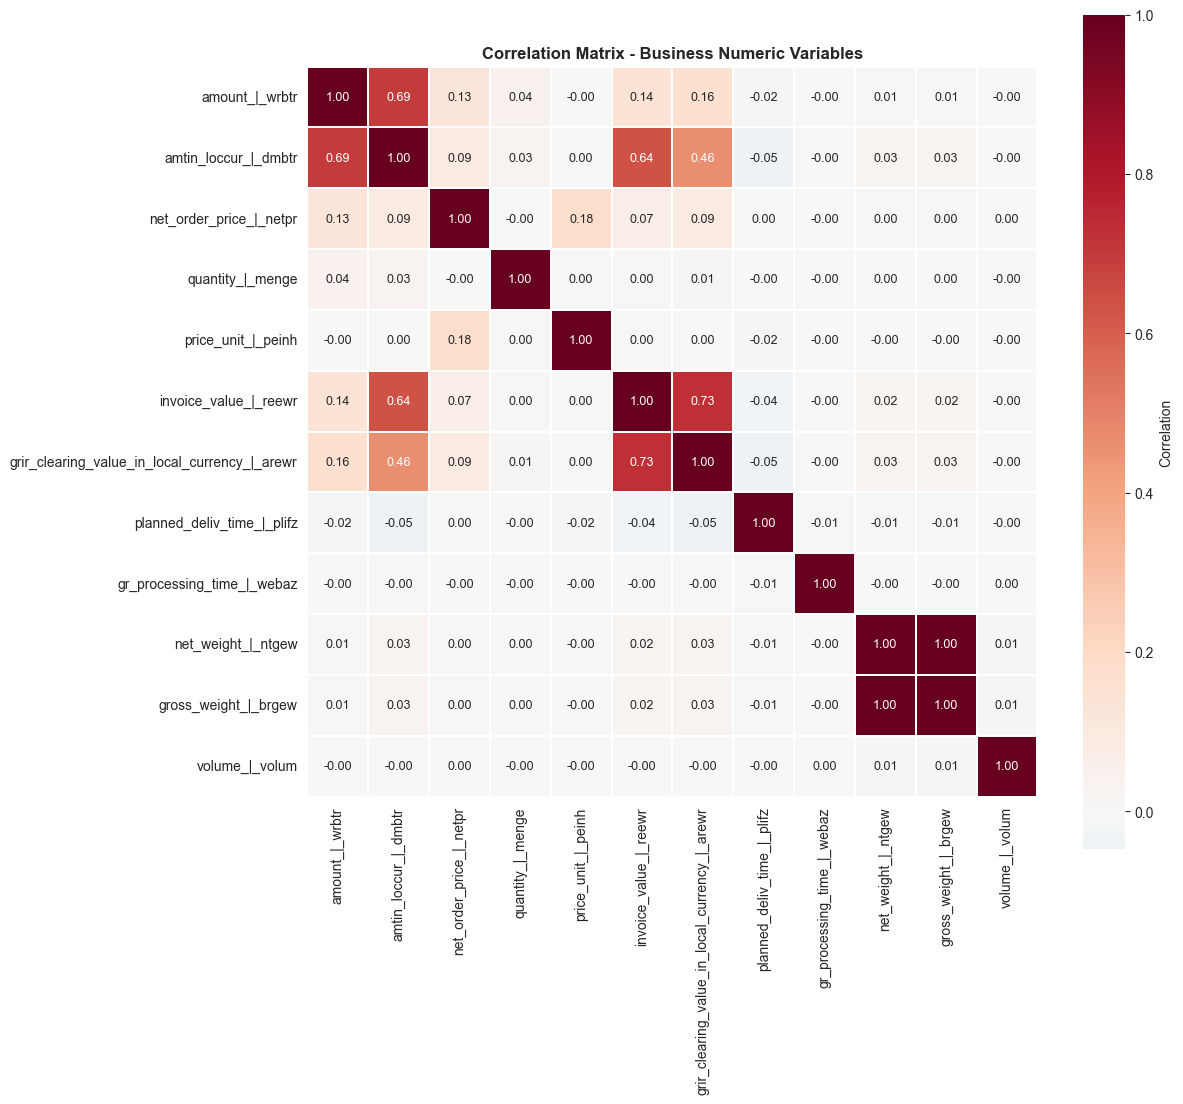


💡 Interpretation hints:
- Missing values show where data quality issues can affect modeling.
- Histograms and boxplots highlight skewness and outliers in monetary fields.
- The correlation matrix helps detect redundant or strongly linked variables.


In [8]:
# EDA visuals: distributions, category breakdowns, and correlation matrix
import matplotlib.ticker as mticker

eda_numeric_cols = [
    col for col in ['amount_|_wrbtr', 'invoice_value_|_reewr']
    if col in df.columns
]

print("\n📊 EDA OVERVIEW")
print("=" * 80)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Selected monetary columns: {len(eda_numeric_cols)}")

# 1) Missing values overview
missing_cols = df.isna().sum().sort_values(ascending=False)
missing_cols = missing_cols[missing_cols > 0].head(15)

if not missing_cols.empty:
    plt.figure(figsize=(14, 6))
    sns.barplot(x=missing_cols.values, y=missing_cols.index, color=FORVIA_COLORS[0])
    plt.title("Top 15 Missing Values by Column", fontweight="bold")
    plt.xlabel("Number of missing values")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

# 2) Distribution of monetary amounts
for col in eda_numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    series = pd.to_numeric(df[col], errors='coerce').dropna()

    sns.histplot(series, bins=40, kde=True, ax=axes[0], color=FORVIA_COLORS[1])
    axes[0].set_title(f"Distribution of {col}", fontweight="bold")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    sns.boxplot(x=series, ax=axes[1], color=FORVIA_COLORS[2])
    axes[1].set_title(f"Outlier View - {col}", fontweight="bold")
    axes[1].set_xlabel(col)
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}"))

    plt.tight_layout()
    plt.show()

# 3) Key business categories
if 'po_history_category_|_bewtp' in df.columns:
    category_counts = df['po_history_category_|_bewtp'].value_counts().reset_index()
    category_counts.columns = ['po_history_category_|_bewtp', 'count']
    colors = FORVIA_COLORS[:len(category_counts)]

    plt.figure(figsize=(12, 5))
    plt.bar(category_counts['po_history_category_|_bewtp'], category_counts['count'], color=colors)
    plt.title("Transaction Count by SAP History Category", fontweight="bold")
    plt.xlabel("PO history category")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# 4) Correlation matrix on business numeric features only
candidate_metrics = [
    'amount_|_wrbtr',
    'amtin_loccur_|_dmbtr',
    'net_order_price_|_netpr',
    'quantity_|_menge',
    'price_unit_|_peinh',
    'invoice_value_|_reewr',
    'grir_clearing_value_in_local_currency_|_arewr',
    'planned_deliv_time_|_plifz',
    'gr_processing_time_|_webaz',
    'net_weight_|_ntgew',
    'gross_weight_|_brgew',
    'volume_|_volum',
]

corr_cols = [col for col in candidate_metrics if col in df.columns]
correlation_df = df[corr_cols].apply(pd.to_numeric, errors='coerce')
correlation_df = correlation_df.loc[:, correlation_df.nunique(dropna=True) > 1]

if correlation_df.shape[1] >= 2:
    corr = correlation_df.corr(numeric_only=True)
    plt.figure(figsize=(min(14, 1 + 0.95 * corr.shape[1]), min(12, 1 + 0.85 * corr.shape[0])))
    sns.heatmap(
        corr,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 9},
        square=True,
        linewidths=0.3,
        cbar_kws={'label': 'Correlation'}
    )
    plt.title("Correlation Matrix - Business Numeric Variables", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough business numeric columns to build a correlation matrix.")

# 5) Quick interpretation hints
print("\n💡 Interpretation hints:")
print("- Missing values show where data quality issues can affect modeling.")
print("- Histograms and boxplots highlight skewness and outliers in monetary fields.")
print("- The correlation matrix helps detect redundant or strongly linked variables.")

## 8️⃣ STATISTICAL PROFILE & DATA QUALITY DEEP DIVE

Cette section reste dans le périmètre du **Data Understanding**. Elle complète l’EDA existante avec une lecture statistique plus robuste des variables métier SAP P2P, afin d’identifier les distributions atypiques, les valeurs extrêmes et les signaux faibles utiles pour la suite du projet.


📐 STATISTICAL PROFILE OF KEY NUMERIC VARIABLES


,column,count,missing_rate,zero_rate,negative_rate,mean,median,std,min,max,skewness,kurtosis,iqr,mad,z_outlier_rate,iqr_outlier_rate
1,invoice_value_|_reewr,616800,0.00%,50.78%,0.00%,"1,524.92",0.00,"15,516.47",0.00,"5,669,888.33",187.78,"61,267.79",273.00,0.00,0.50%,17.27%
5,grir_clearing_value_in_local_currency_|_arewr,616800,0.00%,50.42%,0.00%,"1,522.17",0.00,"12,006.34",0.00,"2,582,768.61",68.20,"10,125.48",280.00,0.00,0.72%,17.20%
3,net_order_price_|_netpr,616800,0.00%,0.00%,0.00%,564.43,37.87,"8,219.61",0.01,"2,964,150.00",194.53,"60,349.65",181.56,35.17,0.25%,15.13%
4,amtin_loccur_|_dmbtr,616800,0.00%,1.39%,0.00%,"3,098.46",275.23,"24,163.65",0.00,"5,669,888.33",124.35,"24,582.67","1,224.06",254.60,0.49%,14.94%
2,quantity_|_menge,616800,0.00%,0.94%,0.00%,77.20,5.00,"5,485.74",0.00,"3,000,000.00",530.73,"290,001.19",13.00,4.00,0.04%,14.35%
0,amount_|_wrbtr,616800,0.00%,1.39%,0.00%,"1,639.99",230.00,"16,380.03",0.00,"5,132,640.00",216.81,"64,032.00",849.00,209.09,0.26%,13.47%


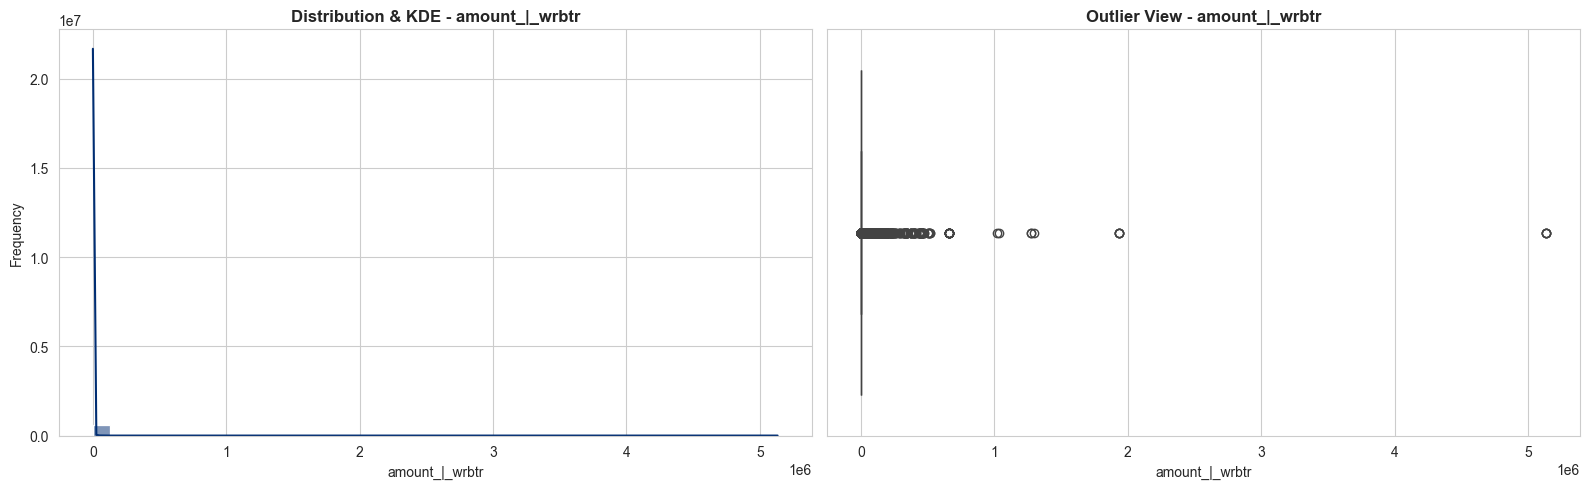


**Lecture métier - `amount_|_wrbtr`**

- **Description du graphique** : vue de la distribution et des valeurs extrêmes de la variable.
- **Observations importantes** : distribution asymétrique, outliers potentiels.
- **Anomalies potentielles détectées** : contrôle des observations au-delà des seuils IQR et Z-score.
- **Impact métier SAP** : peut signaler des montants atypiques, des quantités incohérentes ou des lignes de transaction sensibles.
- **Impact potentiel ML** : variable possiblement non gaussienne, avec besoin de transformation robuste ou de winsorisation.
- **Recommandations Data Preparation** : vérifier la cohérence métier, traiter les extrêmes et tester une transformation logarithmique si la variable est fortement asymétrique.


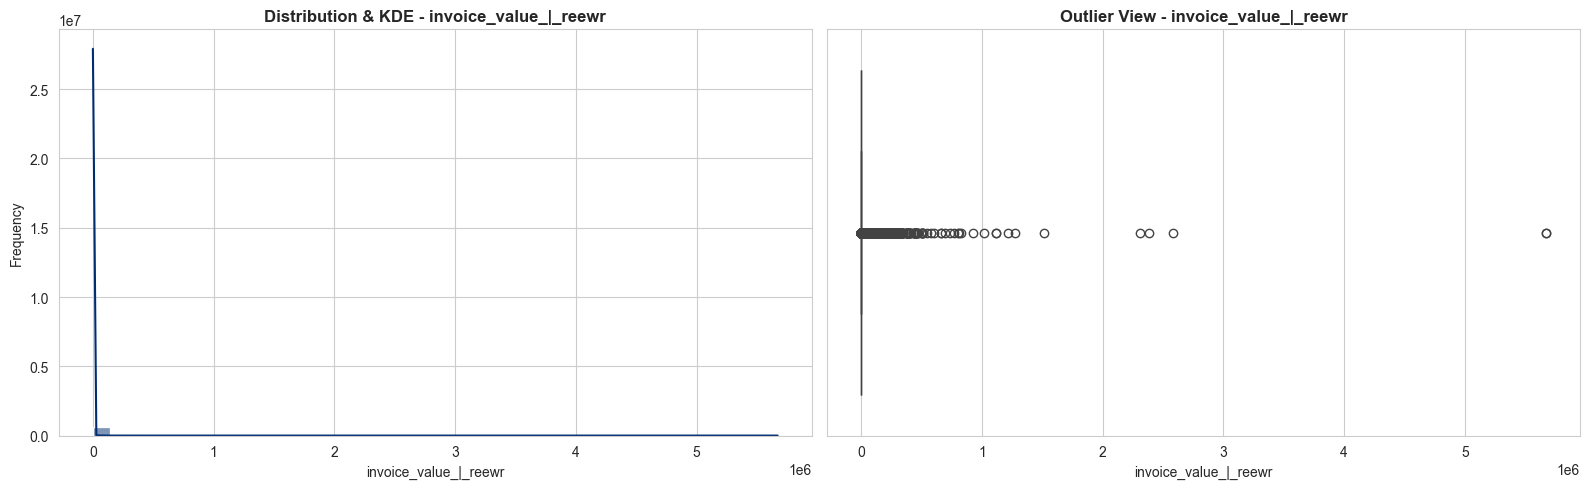


**Lecture métier - `invoice_value_|_reewr`**

- **Description du graphique** : vue de la distribution et des valeurs extrêmes de la variable.
- **Observations importantes** : distribution asymétrique, outliers potentiels, valeurs nulles fréquentes.
- **Anomalies potentielles détectées** : contrôle des observations au-delà des seuils IQR et Z-score.
- **Impact métier SAP** : peut signaler des montants atypiques, des quantités incohérentes ou des lignes de transaction sensibles.
- **Impact potentiel ML** : variable possiblement non gaussienne, avec besoin de transformation robuste ou de winsorisation.
- **Recommandations Data Preparation** : vérifier la cohérence métier, traiter les extrêmes et tester une transformation logarithmique si la variable est fortement asymétrique.


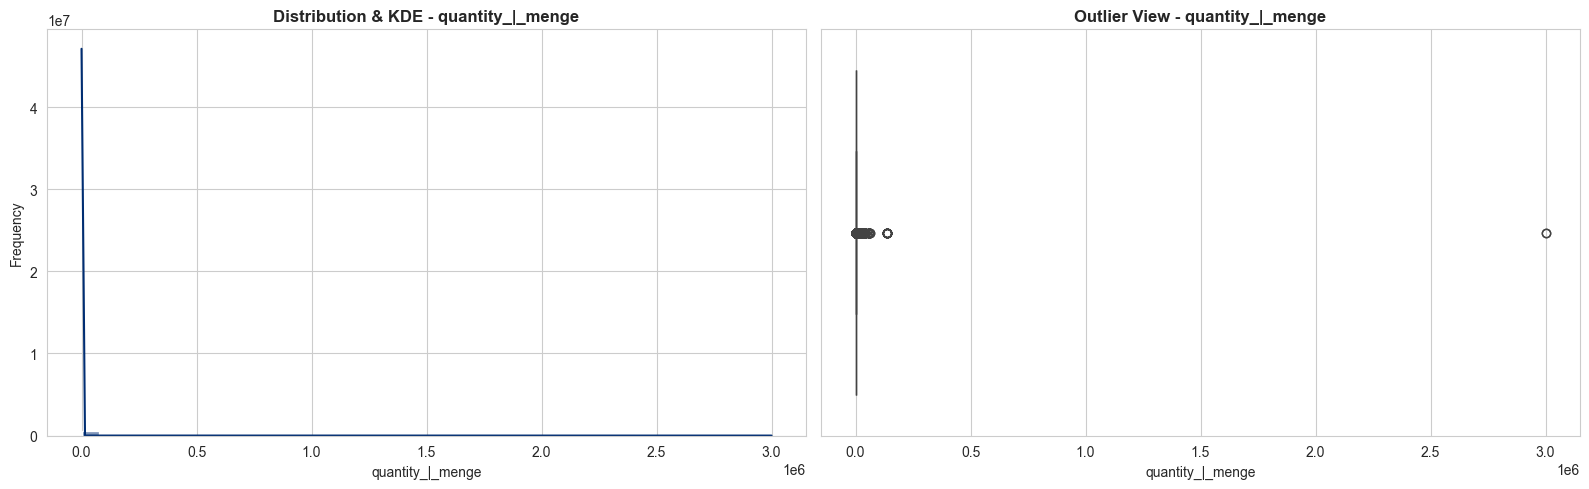


**Lecture métier - `quantity_|_menge`**

- **Description du graphique** : vue de la distribution et des valeurs extrêmes de la variable.
- **Observations importantes** : distribution asymétrique, outliers potentiels.
- **Anomalies potentielles détectées** : contrôle des observations au-delà des seuils IQR et Z-score.
- **Impact métier SAP** : peut signaler des montants atypiques, des quantités incohérentes ou des lignes de transaction sensibles.
- **Impact potentiel ML** : variable possiblement non gaussienne, avec besoin de transformation robuste ou de winsorisation.
- **Recommandations Data Preparation** : vérifier la cohérence métier, traiter les extrêmes et tester une transformation logarithmique si la variable est fortement asymétrique.



🔎 STATISTICAL TAKEAWAYS
- Variables with the strongest asymmetry should be transformed carefully before modeling.
- The IQR and Z-score outlier rates provide a first proxy for suspicious monetary or quantity observations.
- MAD is preferred for robust scaling when SAP data contains extreme business events.

Top skewed variables:


,column,skewness,iqr_outlier_rate,z_outlier_rate
2,quantity_|_menge,530.73,14.35%,0.04%
0,amount_|_wrbtr,216.81,13.47%,0.26%
3,net_order_price_|_netpr,194.53,15.13%,0.25%


In [3]:
from IPython.display import Markdown
from scipy import stats

# Helper functions for robust exploratory analysis

def find_available_columns(candidates):
    """Return the subset of candidate columns that exist in the current dataset."""
    return [col for col in candidates if col in df.columns]


def safe_numeric_series(column_name):
    """Convert a column to numeric safely and drop missing values."""
    return pd.to_numeric(df[column_name], errors='coerce').dropna()


def describe_numeric_series(series):
    """Compute robust statistical descriptors useful for Data Understanding."""
    if series.empty:
        return None

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    mad = (series - series.median()).abs().median()
    mean = series.mean()
    std = series.std(ddof=1)
    z_scores = np.abs(stats.zscore(series, nan_policy='omit')) if len(series) > 2 else np.array([])
    z_outlier_rate = float((z_scores > 3).mean()) if len(z_scores) else 0.0
    iqr_outlier_rate = float(((series < (q1 - 1.5 * iqr)) | (series > (q3 + 1.5 * iqr))).mean()) if iqr > 0 else 0.0

    return {
        'count': int(series.shape[0]),
        'mean': mean,
        'median': series.median(),
        'std': std,
        'min': series.min(),
        'max': series.max(),
        'skewness': series.skew(),
        'kurtosis': series.kurtosis(),
        'iqr': iqr,
        'mad': mad,
        'missing_rate': 0.0,
        'zero_rate': float((series == 0).mean()),
        'negative_rate': float((series < 0).mean()),
        'z_outlier_rate': z_outlier_rate,
        'iqr_outlier_rate': iqr_outlier_rate,
    }


def build_business_commentary(column_name, metrics):
    """Generate a concise business interpretation for each explored variable."""
    notes = []
    if abs(metrics['skewness']) > 1:
        notes.append("distribution asymétrique")
    if metrics['iqr_outlier_rate'] > 0.05 or metrics['z_outlier_rate'] > 0.02:
        notes.append("outliers potentiels")
    if metrics['negative_rate'] > 0:
        notes.append("valeurs négatives à contrôler")
    if metrics['zero_rate'] > 0.05:
        notes.append("valeurs nulles fréquentes")

    note_text = ", ".join(notes) if notes else "pas de signal statistique majeur visible"

    return Markdown(f"""
**Lecture métier - `{column_name}`**

- **Description du graphique** : vue de la distribution et des valeurs extrêmes de la variable.
- **Observations importantes** : {note_text}.
- **Anomalies potentielles détectées** : contrôle des observations au-delà des seuils IQR et Z-score.
- **Impact métier SAP** : peut signaler des montants atypiques, des quantités incohérentes ou des lignes de transaction sensibles.
- **Impact potentiel ML** : variable possiblement non gaussienne, avec besoin de transformation robuste ou de winsorisation.
- **Recommandations Data Preparation** : vérifier la cohérence métier, traiter les extrêmes et tester une transformation logarithmique si la variable est fortement asymétrique.
""")


stat_candidates = find_available_columns([
    'amount_|_wrbtr',
    'invoice_value_|_reewr',
    'quantity_|_menge',
    'net_order_price_|_netpr',
    'amtin_loccur_|_dmbtr',
    'grir_clearing_value_in_local_currency_|_arewr',
])

if stat_candidates:
    stats_rows = []
    for column_name in stat_candidates:
        series = safe_numeric_series(column_name)
        metrics = describe_numeric_series(series)
        if metrics is None:
            continue
        metrics['column'] = column_name
        metrics['missing_rate'] = float(df[column_name].isna().mean())
        stats_rows.append(metrics)

    stats_df = pd.DataFrame(stats_rows)
    stats_df = stats_df[[
        'column', 'count', 'missing_rate', 'zero_rate', 'negative_rate',
        'mean', 'median', 'std', 'min', 'max', 'skewness', 'kurtosis',
        'iqr', 'mad', 'z_outlier_rate', 'iqr_outlier_rate'
    ]].sort_values(by='iqr_outlier_rate', ascending=False)

    print("\n📐 STATISTICAL PROFILE OF KEY NUMERIC VARIABLES")
    print("=" * 100)
    display(stats_df.style.format({
        'missing_rate': '{:.2%}',
        'zero_rate': '{:.2%}',
        'negative_rate': '{:.2%}',
        'mean': '{:,.2f}',
        'median': '{:,.2f}',
        'std': '{:,.2f}',
        'min': '{:,.2f}',
        'max': '{:,.2f}',
        'skewness': '{:,.2f}',
        'kurtosis': '{:,.2f}',
        'iqr': '{:,.2f}',
        'mad': '{:,.2f}',
        'z_outlier_rate': '{:.2%}',
        'iqr_outlier_rate': '{:.2%}',
    }))

    focus_columns = stat_candidates[:3]
    for column_name in focus_columns:
        series = safe_numeric_series(column_name)
        if series.empty:
            continue

        metrics = describe_numeric_series(series)
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        sns.histplot(series, kde=True, bins=40, color=FORVIA_COLORS[0], ax=axes[0])
        axes[0].set_title(f"Distribution & KDE - {column_name}", fontweight='bold')
        axes[0].set_xlabel(column_name)
        axes[0].set_ylabel("Frequency")

        sns.boxplot(x=series, color=FORVIA_COLORS[2], ax=axes[1])
        axes[1].set_title(f"Outlier View - {column_name}", fontweight='bold')
        axes[1].set_xlabel(column_name)

        plt.tight_layout()
        plt.show()

        display(build_business_commentary(column_name, metrics))

    high_skew = stats_df.loc[stats_df['skewness'].abs().sort_values(ascending=False).index].head(3)
    print("\n🔎 STATISTICAL TAKEAWAYS")
    print("- Variables with the strongest asymmetry should be transformed carefully before modeling.")
    print("- The IQR and Z-score outlier rates provide a first proxy for suspicious monetary or quantity observations.")
    print("- MAD is preferred for robust scaling when SAP data contains extreme business events.")
    print("\nTop skewed variables:")
    display(high_skew[['column', 'skewness', 'iqr_outlier_rate', 'z_outlier_rate']].style.format({
        'skewness': '{:,.2f}',
        'iqr_outlier_rate': '{:.2%}',
        'z_outlier_rate': '{:.2%}',
    }))
else:
    print("No numeric business column found for advanced statistical profiling.")

## 9️⃣ SAP P2P BUSINESS EXPLORATION: GR / IR TIMING AND ANOMALIES

Cette partie reste exploratoire. Elle met l’accent sur les incohérences GR / IR visibles dans les données brutes, ainsi que sur les délais métier qui peuvent signaler des retards inhabituels, des écarts de processus ou des cas à investiguer plus tard dans la chaîne Data Preparation / Modeling.


⏱️ GR / IR TIMING ANALYSIS (AVEC VRAI NOM FOURNISSEUR)
Items with both GR and IR dates: 283,027
Average delay: 10.81 days
Median delay: 5.00 days
% > 30 days: 6.73%
% negative delays: 0.67%

Top 15 suppliers:


,supplier_name,count_items,avg_delay,median_delay,pct_delay_gt_30,pct_negative
0,MABEO INDUSTRIES,15409,10.567461,7.0,0.031280,0.0
1,"KROK CZ, S.R.O.",10188,13.487240,8.0,0.090793,0.0
2,RUBIX FRANCE,8651,6.611837,4.0,0.020344,0.0
3,URVINAPOR,5927,22.210562,11.0,0.215792,0.0
4,ARTWELD S R O,5844,2.526694,1.0,0.007871,0.0
5,DAYTON PROGRESS,5734,25.608476,7.0,0.207883,0.0
6,CP TRADE LODZ SP. Z O.O.,4473,11.631344,2.0,0.104628,0.0
7,OŚRODEK USŁUG TECHNICZNYCH MEZAR SP,4054,13.925752,12.0,0.026394,0.0
8,‼DUSICKA JAROSLAV KOV. (USE_259448),3926,16.657412,14.0,0.141111,0.0
9,MX NORM SP. Z O.O.,3744,4.250534,1.0,0.009882,0.0


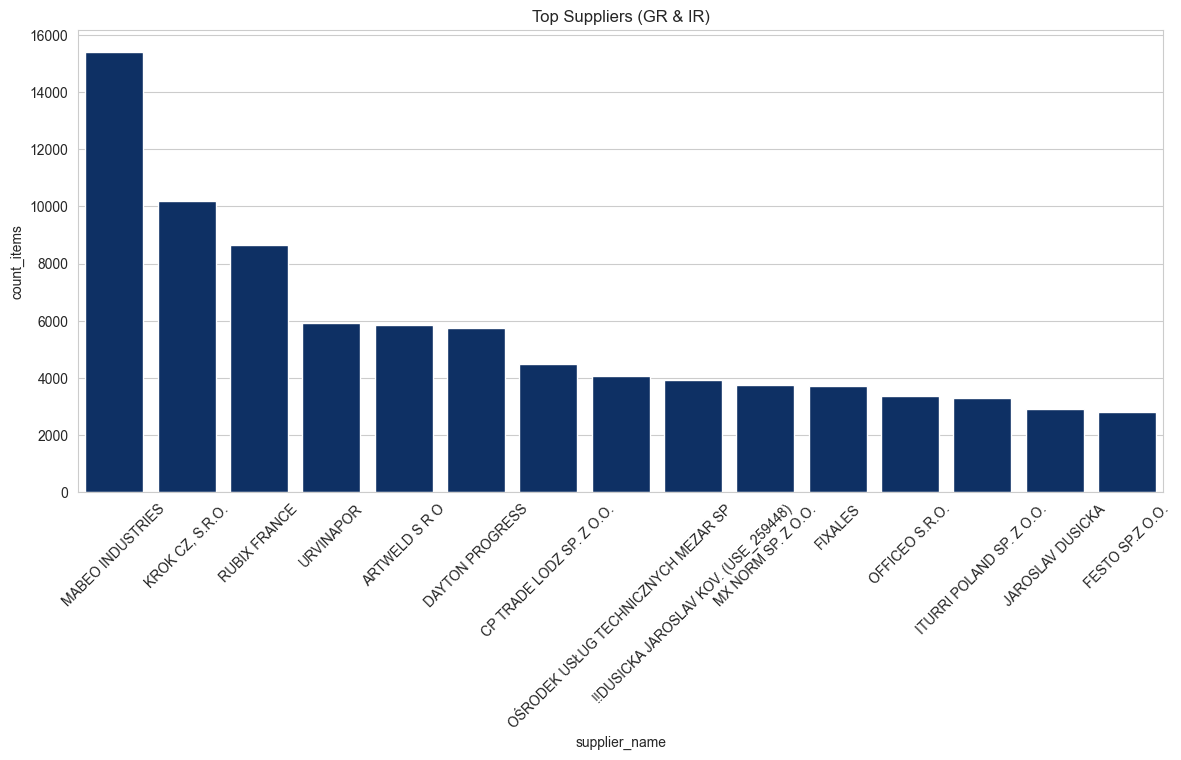

In [17]:
# SAP P2P timing and anomaly exploration
from IPython.display import Markdown

# Use posting date explicitly for GR / IR timing analysis
if 'posting_date_|_budat' in df.columns:
    business_df = df.copy()
    business_df['posting_date_|_budat'] = pd.to_datetime(business_df['posting_date_|_budat'], errors='coerce')

    # ✅ FORCER supplier_name dès le départ
    if 'supplier_name' not in business_df.columns:
        if 'name_1_|_name1' in business_df.columns:
            business_df['supplier_name'] = business_df['name_1_|_name1']
        elif 'supplier_|_lifnr' in business_df.columns:
            business_df['supplier_name'] = business_df['supplier_|_lifnr']

    # Build GR / IR flags
    if 'po_history_category_|_bewtp' in business_df.columns:
        business_df['event_type'] = business_df['po_history_category_|_bewtp'].astype(str).str.upper().str.strip()
        business_df['is_gr_event'] = business_df['event_type'] == 'E'
        business_df['is_ir_event'] = business_df['event_type'] == 'Q'
    else:
        business_df['is_gr_event'] = False
        business_df['is_ir_event'] = False

    key_cols = ['purchasing_document_|_ebeln', 'item_|_ebelp']

    if set(key_cols).issubset(business_df.columns):

        # ✅ GR dates
        gr_dates = (
            business_df[
                (business_df['is_gr_event']) & (business_df['posting_date_|_budat'].notna())
            ][key_cols + ['posting_date_|_budat']]
            .groupby(key_cols, as_index=False)['posting_date_|_budat']
            .min()
            .rename(columns={'posting_date_|_budat': 'first_gr_date'})
        )

        # ✅ IR dates
        ir_dates = (
            business_df[
                (business_df['is_ir_event']) & (business_df['posting_date_|_budat'].notna())
            ][key_cols + ['posting_date_|_budat']]
            .groupby(key_cols, as_index=False)['posting_date_|_budat']
            .min()
            .rename(columns={'posting_date_|_budat': 'first_ir_date'})
        )

        # ✅ merge GR / IR
        timing_df = gr_dates.merge(ir_dates, on=key_cols, how='outer')

        # ✅ compute delay
        timing_df['gr_ir_delay_days'] = (
            timing_df['first_ir_date'] - timing_df['first_gr_date']
        ).dt.days

        timing_df['delay_bucket'] = pd.cut(
            timing_df['gr_ir_delay_days'],
            bins=[-np.inf, -1, 0, 7, 30, 90, np.inf],
            labels=['Negative', 'Same day', '1-7 days', '8-30 days', '31-90 days', '90+ days']
        )

        # ✅ JOIN supplier_name propre
        supplier_map = (
            business_df[
                business_df['supplier_name'].notna()
            ][key_cols + ['supplier_name']]
            .drop_duplicates(subset=key_cols + ['supplier_name'])
            .groupby(key_cols, as_index=False)['supplier_name']
            .first()
        )

        timing_df = timing_df.merge(supplier_map, on=key_cols, how='left')

        # ===================================================
        # 📊 GLOBAL METRICS
        # ===================================================
        print("\n⏱️ GR / IR TIMING ANALYSIS (AVEC VRAI NOM FOURNISSEUR)")
        print("=" * 100)

        delay_series = timing_df['gr_ir_delay_days'].dropna()

        if not delay_series.empty:
            print(f"Items with both GR and IR dates: {delay_series.shape[0]:,}")
            print(f"Average delay: {delay_series.mean():.2f} days")
            print(f"Median delay: {delay_series.median():.2f} days")
            print(f"% > 30 days: {(delay_series > 30).mean():.2%}")
            print(f"% negative delays: {(delay_series < 0).mean():.2%}")

        # ===================================================
        # 📊 SUPPLIER AGGREGATION (CORRIGÉ)
        # ===================================================
        supplier_timing = timing_df.dropna(subset=['supplier_name', 'gr_ir_delay_days'])

        if not supplier_timing.empty:

            supplier_agg = (
                supplier_timing
                .groupby('supplier_name')
                .agg(
                    count_items=('gr_ir_delay_days', 'count'),
                    avg_delay=('gr_ir_delay_days', 'mean'),
                    median_delay=('gr_ir_delay_days', 'median'),
                    pct_delay_gt_30=('gr_ir_delay_days', lambda s: (s > 30).mean()),
                    pct_negative=('gr_ir_delay_days', lambda s: (s < 0).mean())
                )
                .reset_index()
                .sort_values(['count_items'], ascending=False)
                .reset_index(drop=True)  # ✅ propre index
            )

            print("\nTop 15 suppliers:")
            display(supplier_agg.head(15))

            # ✅ plot
            import matplotlib.pyplot as plt
            import seaborn as sns

            top15 = supplier_agg.head(15)

            plt.figure(figsize=(14, 6))
            sns.barplot(data=top15, x='supplier_name', y='count_items')
            plt.xticks(rotation=45)
            plt.title("Top Suppliers (GR & IR)")
            plt.show()

        else:
            print("No supplier data available")

    else:
        print("PO / item keys missing")

else:
    print("No posting_date_|_budat found")

## 10️⃣ SUPPLIER EXPLORATION FOR FUTURE RISK FEATURES

Cette section ne fait pas encore du clustering final. Elle sert à décrire les comportements fournisseurs visibles dans les données brutes, à identifier les concentrations de volume / montant, et à préparer les futures features qui seront utilisées plus tard dans le projet de Machine Learning.

In [16]:
# Supplier exploration for future risk features
from IPython.display import Markdown

# ✅ FORCER le bon champ fournisseur (priorité au nom)
if 'supplier_name' in df.columns:
    supplier_col = 'supplier_name'
elif 'name_1_|_name1' in df.columns:
    df['supplier_name'] = df['name_1_|_name1']
    supplier_col = 'supplier_name'
elif 'supplier_|_lifnr' in df.columns:
    supplier_col = 'supplier_|_lifnr'
else:
    supplier_col = None

if supplier_col:
    supplier_df = df.copy()

    # ✅ NORMALISER supplier_name (important)
    if supplier_col == 'supplier_|_lifnr' and 'supplier_name' in supplier_df.columns:
        supplier_df[supplier_col] = supplier_df['supplier_name'].fillna(supplier_df[supplier_col])

    # === Colonnes optionnelles ===
    amount_col = 'amount_|_wrbtr' if 'amount_|_wrbtr' in supplier_df.columns else None
    event_col = 'po_history_category_|_bewtp' if 'po_history_category_|_bewtp' in supplier_df.columns else None

    date_col = next(
        (col for col in ['posting_date_|_budat', 'document_date_|_bedat', 'entry_date_|_cpudt']
         if col in supplier_df.columns),
        None
    )

    if amount_col:
        supplier_df[amount_col] = pd.to_numeric(supplier_df[amount_col], errors='coerce')

    if date_col:
        supplier_df[date_col] = pd.to_datetime(supplier_df[date_col], errors='coerce')

    # ✅ GROUP BY FOURNISSEUR (VRAI NOM)
    supplier_profile = supplier_df.groupby(supplier_col).agg(
        transaction_count=(supplier_col, 'size'),
        distinct_po_count=('purchasing_document_|_ebeln', 'nunique') if 'purchasing_document_|_ebeln' in supplier_df.columns else (supplier_col, 'size'),
        total_amount=(amount_col, 'sum') if amount_col else (supplier_col, 'size'),
        avg_amount=(amount_col, 'mean') if amount_col else (supplier_col, 'size'),
        median_amount=(amount_col, 'median') if amount_col else (supplier_col, 'size'),
        std_amount=(amount_col, 'std') if amount_col else (supplier_col, 'size'),
    ).reset_index()

    # ✅ FEATURES FINANCIÈRES
    if amount_col:
        supplier_profile['zero_amount_rate'] = supplier_df.groupby(supplier_col)[amount_col].apply(lambda s: (s == 0).mean()).values
        supplier_profile['negative_amount_rate'] = supplier_df.groupby(supplier_col)[amount_col].apply(lambda s: (s < 0).mean()).values
        supplier_profile['amount_volatility'] = supplier_profile['std_amount'] / supplier_profile['avg_amount'].abs().replace(0, np.nan)

    # ✅ FEATURES P2P
    if event_col:
        supplier_profile['gr_share'] = supplier_df.groupby(supplier_col)[event_col].apply(lambda s: (s.astype(str).str.upper() == 'E').mean()).values
        supplier_profile['ir_share'] = supplier_df.groupby(supplier_col)[event_col].apply(lambda s: (s.astype(str).str.upper() == 'Q').mean()).values
        supplier_profile['history_imbalance'] = (supplier_profile['gr_share'].fillna(0) - supplier_profile['ir_share'].fillna(0)).abs()
    else:
        supplier_profile[['gr_share', 'ir_share', 'history_imbalance']] = np.nan

    # ✅ ACTIVITÉ TEMPORELLE
    if date_col:
        supplier_profile['active_months'] = supplier_df.groupby(supplier_col)[date_col].apply(
            lambda s: s.dt.to_period('M').nunique()
        ).values
    else:
        supplier_profile['active_months'] = np.nan

    # ✅ PROXY RISQUE
    proxy_cols = ['negative_amount_rate', 'zero_amount_rate', 'amount_volatility', 'history_imbalance']

    proxy_components = [
        supplier_profile[c].rank(pct=True).fillna(0)
        for c in proxy_cols if c in supplier_profile.columns
    ]

    supplier_profile['exploratory_risk_proxy'] = (
        sum(proxy_components) / len(proxy_components)
        if proxy_components else 0.0
    )

    supplier_profile['amount_share'] = supplier_profile['total_amount'] / supplier_profile['total_amount'].sum()

    supplier_profile = supplier_profile.sort_values(
        ['exploratory_risk_proxy', 'total_amount'],
        ascending=[False, False]
    )

    print("\n👥 SUPPLIER EXPLORATION PROFILE (CORRIGÉ)")
    print("=" * 100)

    display(supplier_profile.head(15).style.format({
        'total_amount': '{:,.2f}',
        'avg_amount': '{:,.2f}',
        'median_amount': '{:,.2f}',
        'std_amount': '{:,.2f}',
        'zero_amount_rate': '{:.2%}',
        'negative_amount_rate': '{:.2%}',
        'amount_volatility': '{:.2f}',
        'gr_share': '{:.2%}',
        'ir_share': '{:.2%}',
        'history_imbalance': '{:.2%}',
        'active_months': '{:,.0f}',
        'exploratory_risk_proxy': '{:.2f}',
        'amount_share': '{:.2%}',
    }))

else:
    print('❌ No supplier column found')


👥 SUPPLIER EXPLORATION PROFILE (CORRIGÉ)


,supplier_name,transaction_count,distinct_po_count,total_amount,avg_amount,median_amount,std_amount,zero_amount_rate,negative_amount_rate,amount_volatility,gr_share,ir_share,history_imbalance,active_months,exploratory_risk_proxy,amount_share
1037,JENDAMARK AUTOMATION (PTY) LTD,84,20,"358,186.75","4,264.13",0.00,"13,477.32",79.76%,0.00%,3.16,89.29%,10.71%,78.57%,13,0.86,0.04%
1088,KIVNON FRANCE,12,6,966.00,80.50,0.00,183.19,66.67%,0.00%,2.28,83.33%,16.67%,66.67%,3,0.86,0.00%
670,FAURECIA EXHAUST SYSTEMS S.R.O.,59,2,"10,518.79",178.28,0.00,392.73,64.41%,0.00%,2.20,66.10%,1.69%,64.41%,4,0.86,0.00%
1464,PERIFERI,40,13,"19,682.00",492.05,0.00,917.17,60.00%,0.00%,1.86,80.00%,20.00%,60.00%,3,0.85,0.00%
2234,‼FEINTOOL TECHNOLOGIE (USE_258560),91,9,"140,509.93","1,544.07",33.32,"4,463.85",29.67%,0.00%,2.89,53.85%,24.18%,29.67%,12,0.85,0.01%
394,CLE DE 13 PRODUCTIQUE,17,13,"7,268.08",427.53,0.00,809.74,52.94%,0.00%,1.89,76.47%,23.53%,52.94%,10,0.85,0.00%
1568,QUAKER HOUGHTON SALES BV,119,37,"6,835,766.04","57,443.41","1,964.60","182,834.17",15.13%,0.00%,3.18,59.66%,35.29%,24.37%,23,0.84,0.68%
1842,SINTRON INDUSTRIE-ELEKTRIK GMBH,3,2,481.80,160.60,21.00,260.19,33.33%,0.00%,1.62,100.00%,0.00%,100.00%,1,0.84,0.00%
1213,LÉKÁRNA U SOUDU S.R.O.,41,5,"46,303.72","1,129.36",150.00,"2,665.52",21.95%,0.00%,2.36,60.98%,39.02%,21.95%,3,0.84,0.00%
1588,RD TECHNOLOGIES SAS,30,16,"292,585.61","9,752.85",264.00,"22,549.79",26.67%,0.00%,2.31,60.00%,40.00%,20.00%,13,0.84,0.03%


## ✅ KEY INSIGHTS & NEXT STEPS

**Key Findings:**
- Dataset structure remains intact and ready for downstream processing.
- Advanced statistical profiling highlights strong asymmetry and outliers on monetary and quantity fields.
- GR / IR timing analysis shows a typical delay pattern, with a non-negligible share of long delays and negative delays to investigate.
- Supplier exploration reveals spend concentration and a first risk-oriented supplier view for future feature engineering.
- The notebook now contains robust handling for missing columns and business-oriented interpretations under each figure.

**Business Impact:**
- Better visibility on SAP P2P process quality.
- Clear identification of suspicious transaction patterns and operational exceptions.
- Stronger basis for anomaly detection and supplier risk analysis.

**Data Science Next Steps:**
- Proceed to Data Preparation with the cleaned and validated signals from this notebook.
- Engineer supplier-level and temporal features from the explored signals.
- Reserve final clustering, anomaly modeling, and ML training for the dedicated Modeling stage.

**Scope Reminder:**
- This notebook stays in the Data Understanding phase.
- It does not replace Data Preparation, Feature Engineering, or Modeling.

In [ ]:
# 1. Charger les données
df = spark.read.csv("../../data/Contracts.csv", header=True, inferSchema=True)

# 2. Transformer les données
df_transformed = df.withColumn(
    "po_item_key",
    F.concat_ws("_",
        F.col("purchasing_document_|_ebeln"),
        F.col("item_|_ebelp")
    )
)

# 3. Ajouter colonnes
df_transformed = df_transformed.withColumn(
    "doc_number",
    F.split(F.col("po_item_key"), "_")[0]
).withColumn(
    "item_number",
    F.split(F.col("po_item_key"), "_")[1]
)

# 4. Afficher
df_transformed.show(5)

: 